# Zebrafish hematopoiesis: GraphVelo from official cell annotations

This notebook starts again from raw `spliced`/`unspliced` counts and the official
ZEBRAHUB hematopoietic/endothelial lineage object. Biological names are **never** inferred from numeric
clusters, keywords, regular expressions, or a cluster-to-name dictionary.

The defining exact-ID merge is:

```python
official_fine_cell_type = lineage.obs["annotation"].reindex(cell_ids)
```

Clusters remain audit metadata only. The main outputs are official-label inventories,
data-driven candidate markers, GraphVelo velocities, real-time-constrained transition weights,
and optional ODE trajectories chosen from official labels.


## 0. Configuration

Edit the two paths only if your filenames differ. `INPUT_H5AD` supplies expression,
`spliced`, and `unspliced`. `LINEAGE_H5AD` supplies official fine annotations,
experimental timepoint, and fish. The objects are joined only by exact cell IDs.

The official ZEBRAHUB file is
`zf_atlas_hematopoetic_endothelial_v4_release.h5ad` (206.6 MB). If it was downloaded
as `~/dynamo/Lineage.h5ad`, the configuration below works unchanged.


In [54]:
from pathlib import Path
import json
import platform
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import scanpy as sc
import scipy
import scipy.sparse as sp
import seaborn as sns

SEED = 0
np.random.seed(SEED)

# ---- INPUT PATHS ----
PROJECT_DIR = Path.home() / "dynamo" / "blood_graphvelo_official"
INPUT_H5AD = Path.home() / "dynamo" / "zebrahub_full_velocity.h5ad"
LINEAGE_H5AD = Path.home() / "dynamo" / "lineage.h5ad"

# These are official lineage.obs columns, not names invented in this notebook.
LINEAGE_ANNOTATION_COL = "annotation"
LINEAGE_TIMEPOINT_COL = "timepoint"

# Optional: after reviewing the official inventory, list exact official labels to model.
# None means use every official label with enough cells.
MODEL_FINE_LABELS = None

# Optional ODE configuration. Use exact official labels from the inventory.
# Example only after inspection: [("branch_name", ["official_start", "official_target"])]
ODE_BRANCHES = []
HSPC_OFFICIAL_LABEL = None

RESULTS_DIR = PROJECT_DIR / "results"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
FIGURE_DIR = RESULTS_DIR / "figures"
for path in (RESULTS_DIR, CHECKPOINT_DIR, FIGURE_DIR):
    path.mkdir(parents=True, exist_ok=True)

N_HVG = 2000
N_PCS = 50
N_NEIGHBORS = 30
# Keep ODE interpolation local and consistent with the 30-neighbor cell graph.
ODE_K_NEIGHBORS = 30
MIN_CELLS_PER_FINE_TYPE = 30
TIME_TOLERANCE_HPF = 3.0

print("Python:", platform.python_version())
print("AnnData:", ad.__version__)
print("Scanpy:", sc.__version__)
print("SciPy:", scipy.__version__)
print("Velocity input:", INPUT_H5AD)
print("Official lineage input:", LINEAGE_H5AD)


Python: 3.11.15
AnnData: 0.10.9
Scanpy: 1.11.5
SciPy: 1.16.3
Velocity input: /net/dali/home/mscbio/jis322/dynamo/zebrahub_full_velocity.h5ad
Official lineage input: /net/dali/home/mscbio/jis322/dynamo/lineage.h5ad


/tmp/ipykernel_431891/2695008897.py:53: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy:", sc.__version__)


## 1. Source audit and annotation provenance

The notebook independently opens the velocity and official lineage objects. It requires
raw splicing layers and literal official annotation/timepoint columns. Existing PCA,
UMAP, neighbors, velocities, and manually created names are ignored.


In [57]:
# Fail early with an informative path if either required file is absent.
assert INPUT_H5AD.exists(), f"Velocity file not found: {INPUT_H5AD}"
assert LINEAGE_H5AD.exists(), f"Lineage file not found: {LINEAGE_H5AD}"

# Backed mode avoids loading the 21-GB velocity object fully into RAM.
source = ad.read_h5ad(INPUT_H5AD, backed="r")
lineage = ad.read_h5ad(LINEAGE_H5AD, backed="r")

assert source.obs_names.is_unique, "Velocity cell IDs are not unique."
assert lineage.obs_names.is_unique, "Lineage cell IDs are not unique."
assert {"spliced", "unspliced"}.issubset(source.layers.keys())
assert LINEAGE_ANNOTATION_COL in lineage.obs.columns, (
    f"Missing lineage.obs[{LINEAGE_ANNOTATION_COL!r}]. Available columns:\n"
    f"{lineage.obs.columns.tolist()}"
)
assert LINEAGE_TIMEPOINT_COL in lineage.obs.columns, (
    f"Missing lineage.obs[{LINEAGE_TIMEPOINT_COL!r}]. Available columns:\n"
    f"{lineage.obs.columns.tolist()}"
)

print("Velocity shape:", source.shape)
print("Lineage shape:", lineage.shape)
print("Velocity raw layers:", list(source.layers.keys()))
print("Existing velocity obsm (ignored):", list(source.obsm.keys()))
print("Official fine annotation column:", LINEAGE_ANNOTATION_COL)
display(lineage.obs[LINEAGE_ANNOTATION_COL].value_counts(dropna=False))


Velocity shape: (120800, 3000)
Lineage shape: (5441, 27435)
Velocity raw layers: ['Ms', 'Mu', 'counts', 'fit_t', 'fit_tau', 'fit_tau_', 'matrix', 'spliced', 'unspliced', 'variance_velocity', 'velocity', 'velocity_u']
Existing velocity obsm (ignored): ['X_pca', 'X_umap', 'velocity_umap']
Official fine annotation column: annotation


annotation
erythroblast                              2358
macrophage                                 817
hematopoietic_stem_and_progenitor_HSPC     655
neutrophil                                 507
non_specific_hematopoietic                 464
macrophage_immature                        319
microglia                                  193
innate-lymphoid-cell                       113
thymocyte                                   15
Name: count, dtype: int64

## 2. Exact cell-ID alignment with the official lineage object

Only exact shared cell IDs are used. `official_fine_cell_type` is copied directly from
`lineage.obs["annotation"]`. Numeric clusters never participate in naming.


In [58]:
def first_existing(columns, candidates, required=True):
    for candidate in candidates:
        if candidate in columns:
            return candidate
    if required:
        raise KeyError(f"None of these columns exists: {candidates}")
    return None

# Fish is taken from official lineage metadata. Cluster is optional audit metadata.
FISH_COL = first_existing(lineage.obs.columns, ["fish", "official_fish"])
CLUSTER_COL = first_existing(
    source.obs.columns, ["clusters", "seurat_clusters"], required=False
)

# Preserve velocity-object order; do not fuzzy-match or match by cluster.
candidate_ids = source.obs_names[source.obs_names.isin(lineage.obs_names)]
official_fine = lineage.obs[LINEAGE_ANNOTATION_COL].reindex(candidate_ids)
official_timepoint = lineage.obs[LINEAGE_TIMEPOINT_COL].reindex(candidate_ids)
official_fish = lineage.obs[FISH_COL].reindex(candidate_ids)

merge_audit = pd.Series({
    "velocity_cells": source.n_obs,
    "lineage_cells": lineage.n_obs,
    "exact_shared_cell_ids": len(candidate_ids),
    "lineage_match_fraction": len(candidate_ids) / lineage.n_obs,
    "missing_fine_annotation": int(official_fine.isna().sum()),
    "missing_timepoint": int(official_timepoint.isna().sum()),
    "missing_fish": int(official_fish.isna().sum()),
}, name="n_cells")
display(merge_audit)

assert len(candidate_ids) > 0, "No exact shared cell IDs between velocity and lineage."
assert official_fine.notna().all()
assert official_timepoint.notna().all()
assert official_fish.notna().all()
assert official_fine.astype(str).str.strip().ne("").all(), "Blank official labels found."

print("Official fine labels:")
display(official_fine.value_counts().rename("n_cells").to_frame())


velocity_cells             120800.0
lineage_cells                5441.0
exact_shared_cell_ids        5441.0
lineage_match_fraction          1.0
missing_fine_annotation         0.0
missing_timepoint               0.0
missing_fish                    0.0
Name: n_cells, dtype: float64

Official fine labels:


,n_cells
annotation,
erythroblast,2358
macrophage,817
hematopoietic_stem_and_progenitor_HSPC,655
neutrophil,507
non_specific_hematopoietic,464
macrophage_immature,319
microglia,193
innate-lymphoid-cell,113
thymocyte,15


## 3. Official fine-annotation inventory

The inventory reports official biological labels against hpf, fish, and numeric cluster.
The cluster column is included only to audit heterogeneity; it never determines a name.


In [59]:
# Start from velocity metadata so cluster values remain available for QC only.
audit_obs = source.obs.loc[candidate_ids].copy()

# Add official metadata by exact cell-ID alignment. These assignments do not use row
# position, cluster number, keywords, or a hand-written biological naming dictionary.
audit_obs["official_fine_cell_type"] = official_fine.reindex(
    audit_obs.index
).to_numpy()
audit_obs["timepoint"] = official_timepoint.reindex(audit_obs.index).to_numpy()
audit_obs["fish_id"] = official_fish.reindex(audit_obs.index).astype(str).to_numpy()
audit_obs["cluster_label"] = (
    audit_obs[CLUSTER_COL].astype(str) if CLUSTER_COL is not None else "not_available"
)

# Parse experimental time labels such as 16hpf, 2dpf, and 10dpf.
# This is a unit conversion, not pseudotime and not a biological label mapping.
timepoint_text = audit_obs["timepoint"].astype("string").str.strip().str.lower()
parsed_timepoint = timepoint_text.str.extract(
    r"^(?P<number>\d+(?:\.\d+)?)(?P<unit>hpf|dpf)$"
)
parsed_number = pd.to_numeric(parsed_timepoint["number"], errors="coerce")

# Convert days post fertilization into hours post fertilization: 1 dpf = 24 hpf.
audit_obs["hpf_numeric"] = np.where(
    parsed_timepoint["unit"].eq("dpf"),
    parsed_number * 24.0,
    parsed_number,
)
audit_obs["hpf_numeric"] = pd.to_numeric(
    audit_obs["hpf_numeric"], errors="coerce"
)

# Show the conversion table before asserting, so any unsupported value is visible.
timepoint_conversion_audit = (
    audit_obs[["timepoint", "hpf_numeric"]]
    .drop_duplicates()
    .sort_values("hpf_numeric")
)
display(timepoint_conversion_audit)

failed_timepoints = (
    audit_obs.loc[audit_obs["hpf_numeric"].isna(), "timepoint"]
    .value_counts(dropna=False)
)
if len(failed_timepoints):
    display(failed_timepoints.rename("n_failed_cells").to_frame())

# Assertions belong after parsing and diagnostics—not before hpf_numeric exists.
assert audit_obs["official_fine_cell_type"].notna().all(), (
    "Some shared cells lack lineage.obs['annotation']."
)
assert audit_obs["hpf_numeric"].notna().all(), (
    "Some lineage timepoint values could not be converted to hpf:\n"
    f"{failed_timepoints.to_string()}"
)

inventory = (
    audit_obs.groupby(
        ["official_fine_cell_type", "hpf_numeric", "cluster_label"],
        dropna=False, observed=True,
    )
    .agg(n_cells=("fish_id", "size"), n_fish=("fish_id", "nunique"))
    .reset_index()
    .sort_values(["official_fine_cell_type", "hpf_numeric", "n_cells"],
                 ascending=[True, True, False])
)
inventory.to_csv(RESULTS_DIR / "official_fine_annotation_inventory.csv", index=False)
display(inventory)


,timepoint,hpf_numeric
cell_id,,
TDR36_GGAGATGAGAAGGCTC-1,12hpf,12.0
TDR22_GGGTCACCAGCGCGTT-1,14hpf,14.0
TDR42_GAGTTTGCAACTCGAT-1,16hpf,16.0
TDR27_GTCTACCTCATTGCTT-1,19hpf,19.0
TDR46_GTGTCCTAGGATATAC-1,24hpf,24.0
TDR48_TATCCTAAGCGTATGG-1,2dpf,48.0
TDR68_CTGTGAAAGTGCTACT-1,3dpf,72.0
TDR51_TCATCCGCAACCTATG-1,5dpf,120.0
TDR74_TCACACCAGAGTTCGG-1,10dpf,240.0


,official_fine_cell_type,hpf_numeric,cluster_label,n_cells,n_fish
0,erythroblast,12.0,39,6,2
1,erythroblast,14.0,23,32,4
2,erythroblast,14.0,24,1,1
3,erythroblast,14.0,35,1,1
4,erythroblast,16.0,23,102,4
...,...,...,...,...,...
132,non_specific_hematopoietic,240.0,23,2,1
134,non_specific_hematopoietic,240.0,35,1,1
135,non_specific_hematopoietic,240.0,39,1,1
136,thymocyte,120.0,24,1,1


In [60]:
fine_annotation_summary = (
    audit_obs.groupby("official_fine_cell_type", observed=True)
    .agg(
        n_cells=("fish_id", "size"),
        n_fish=("fish_id", "nunique"),
        first_hpf=("hpf_numeric", "min"),
        last_hpf=("hpf_numeric", "max"),
        n_numeric_clusters=("cluster_label", "nunique"),
    )
    .sort_values("n_cells", ascending=False)
)
display(fine_annotation_summary)
fine_annotation_summary.to_csv(RESULTS_DIR / "official_fine_annotation_summary.csv")

print("GATE 1 PASSED: names come directly from lineage.obs['annotation'].")
print("Review the complete inventory before running the modeling sections.")


,n_cells,n_fish,first_hpf,last_hpf,n_numeric_clusters
official_fine_cell_type,,,,,
erythroblast,2358,32,12.0,240.0,8
macrophage,817,30,14.0,240.0,3
hematopoietic_stem_and_progenitor_HSPC,655,28,14.0,240.0,4
neutrophil,507,21,16.0,240.0,3
non_specific_hematopoietic,464,33,12.0,240.0,8
macrophage_immature,319,31,12.0,240.0,7
microglia,193,16,12.0,240.0,3
innate-lymphoid-cell,113,10,24.0,240.0,2
thymocyte,15,5,120.0,240.0,1


GATE 1 PASSED: names come directly from lineage.obs['annotation'].
Review the complete inventory before running the modeling sections.


## 4. Build a fresh in-memory blood object

Only exact lineage-matched cells are copied. Raw spliced and unspliced matrices are
preserved, while inherited dimensional reductions and graphs are discarded.


In [61]:
# Avoid source[candidate_ids, :].to_memory(): it attempts to materialize every
# inherited obsm/obsp/layer in the 21-GB backed object. Read only the required
# matrices and metadata, preserving the exact candidate-ID order.
candidate_ids = pd.Index(candidate_ids).astype(str)
candidate_pos = source.obs_names.get_indexer(candidate_ids)
assert (candidate_pos >= 0).all(), "Some candidate IDs are absent from source."

selected_obs = source.obs.iloc[candidate_pos].copy()
selected_var = source.var.copy()
S = sp.csr_matrix(source.layers["spliced"][candidate_pos, :])
U = sp.csr_matrix(source.layers["unspliced"][candidate_pos, :])
assert selected_obs.index.equals(candidate_ids)
assert S.shape == U.shape == (len(candidate_ids), source.n_vars)

source.file.close()
lineage.file.close()
del source, lineage

counts = (S + U).tocsr()

blood_clean = ad.AnnData(
    X=counts.copy(), obs=selected_obs, var=selected_var
)
blood_clean.layers["counts"] = counts.copy()
blood_clean.layers["spliced"] = S.copy()
blood_clean.layers["unspliced"] = U.copy()

# Copy the already-audited metadata by exact cell ID.
# No cluster-number dictionary and no row-position-based assignment is used.
aligned_audit = audit_obs.reindex(blood_clean.obs_names)
blood_clean.obs["official_fine_cell_type"] = aligned_audit[
    "official_fine_cell_type"
].to_numpy()
blood_clean.obs["timepoint"] = aligned_audit["timepoint"].to_numpy()
blood_clean.obs["hpf"] = aligned_audit["hpf_numeric"].astype(float).to_numpy()
blood_clean.obs["fish_id"] = aligned_audit["fish_id"].astype(str).to_numpy()

gene_totals = np.asarray(counts.sum(axis=0)).ravel()
blood_clean = blood_clean[:, gene_totals > 0].copy()

assert blood_clean.obs_names.equals(pd.Index(candidate_ids))
assert blood_clean.obs["official_fine_cell_type"].notna().all()
assert blood_clean.obs["hpf"].notna().all()
assert blood_clean.obs_names.is_unique
print(blood_clean)


AnnData object with n_obs × n_vars = 5441 × 2986
    obs: 'clusters', 'seurat_clusters', 'timepoint', 'fish', 'initial_size_spliced', 'initial_size_unspliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'official_fine_cell_type', 'hpf', 'fish_id'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'gene_count_corr', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'fit_r2'
    layers: 'counts', 'spliced', 'unspliced'


## 5. Biological names remain official

There is deliberately no `SUBTYPE_RULES`, regex classifier, or cluster-name mapping.
The modeling label is an exact copy of `official_fine_cell_type`. If a broader lineage
grouping is later needed, create it as a separately sourced biological ontology table—
never by interpreting numeric cluster IDs.


In [62]:
blood_clean.obs["model_cell_type"] = pd.Categorical(
    blood_clean.obs["official_fine_cell_type"]
)

identity_check = pd.crosstab(
    blood_clean.obs["official_fine_cell_type"],
    blood_clean.obs["model_cell_type"],
)
display(identity_check)

off_diagonal = identity_check.to_numpy().sum() - np.trace(identity_check.to_numpy())
assert off_diagonal == 0, "Model labels differ from official fine annotations."

official_counts = blood_clean.obs["official_fine_cell_type"].value_counts()
display(official_counts.rename("n_cells").to_frame())
official_counts.rename("n_cells").to_csv(
    RESULTS_DIR / "official_fine_cell_type_counts.csv"
)


model_cell_type,erythroblast,hematopoietic_stem_and_progenitor_HSPC,innate-lymphoid-cell,macrophage,macrophage_immature,microglia,neutrophil,non_specific_hematopoietic,thymocyte
official_fine_cell_type,,,,,,,,,
erythroblast,2358,0,0,0,0,0,0,0,0
hematopoietic_stem_and_progenitor_HSPC,0,655,0,0,0,0,0,0,0
innate-lymphoid-cell,0,0,113,0,0,0,0,0,0
macrophage,0,0,0,817,0,0,0,0,0
macrophage_immature,0,0,0,0,319,0,0,0,0
microglia,0,0,0,0,0,193,0,0,0
neutrophil,0,0,0,0,0,0,507,0,0
non_specific_hematopoietic,0,0,0,0,0,0,0,464,0
thymocyte,0,0,0,0,0,0,0,0,15


,n_cells
official_fine_cell_type,
erythroblast,2358
macrophage,817
hematopoietic_stem_and_progenitor_HSPC,655
neutrophil,507
non_specific_hematopoietic,464
macrophage_immature,319
microglia,193
innate-lymphoid-cell,113
thymocyte,15


## 6. Data-driven candidate-marker discovery without relabeling

No hand-written marker dictionary is used. Genes are ranked directly from the expression
data by comparing each official ZEBRAHUB class against the remaining classes. These are
data-derived candidate markers for QC, not independently validated biomarkers, and they
never assign or rename a cell.


,official_fine_cell_type,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
4,erythroblast,hbae1.3,54.996449,7.367101,0.000000e+00,0.000000e+00,0.963953,0.390204
5,erythroblast,hbbe1.3,54.145729,7.284439,0.000000e+00,0.000000e+00,0.962256,0.481674
0,erythroblast,hbae3,56.294945,7.270494,0.000000e+00,0.000000e+00,0.977947,0.615310
2,erythroblast,hbae1.3-1,55.458435,7.203584,0.000000e+00,0.000000e+00,0.929177,0.179046
1,erythroblast,hbbe1.1,56.293018,7.108180,0.000000e+00,0.000000e+00,0.968617,0.537464
...,...,...,...,...,...,...,...,...
23908,thymocyte,bcl11ba,5.398007,6.208471,6.738514e-08,9.581525e-06,0.866667,0.096203
23906,thymocyte,sat1a.1,5.549603,5.998657,2.863199e-08,4.499743e-06,0.866667,0.128824
23902,thymocyte,ncaldb,5.765391,5.537986,8.146870e-09,1.621770e-06,0.933333,0.207151
23893,thymocyte,laptm5,6.444031,5.461966,1.163416e-10,5.789933e-08,1.000000,0.485809


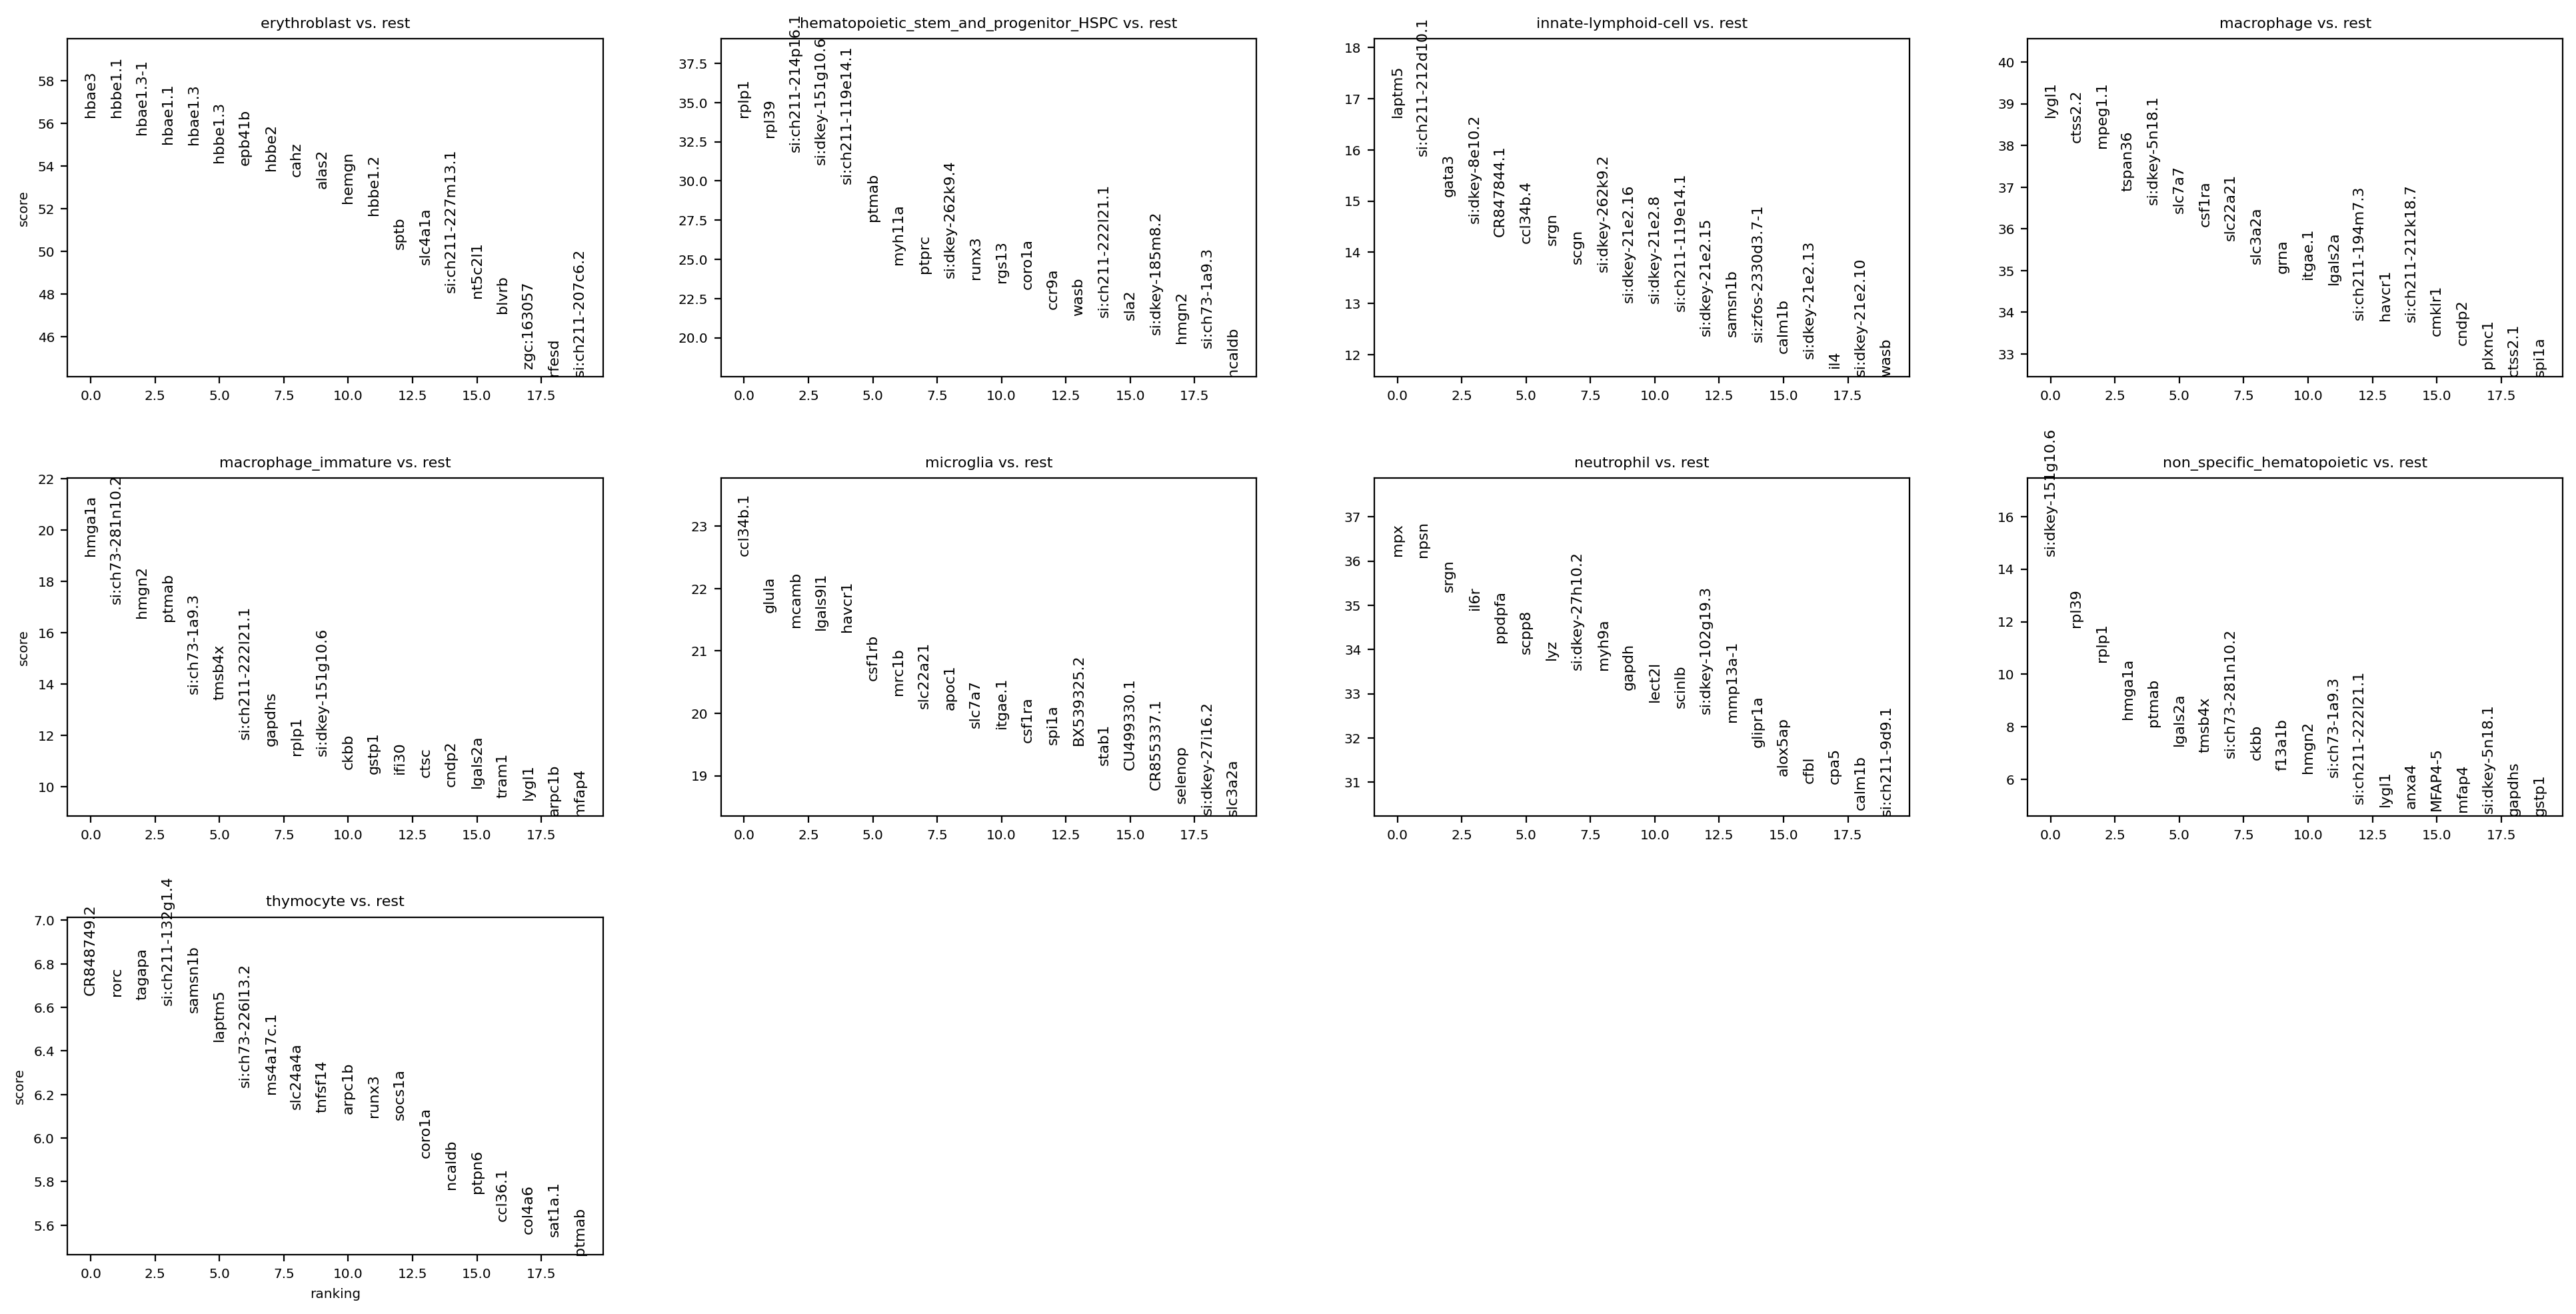

In [63]:
marker_data = blood_clean.copy()
marker_data.X = marker_data.layers["counts"].copy()
sc.pp.normalize_total(marker_data, target_sum=1e4)
sc.pp.log1p(marker_data)
marker_data.obs["official_fine_cell_type"] = marker_data.obs[
    "official_fine_cell_type"
].astype("category")

sc.tl.rank_genes_groups(
    marker_data,
    groupby="official_fine_cell_type",
    reference="rest",
    method="wilcoxon",
    use_raw=False,
    pts=True,
)

marker_tables = []
for official_label in marker_data.obs["official_fine_cell_type"].cat.categories:
    table = sc.get.rank_genes_groups_df(marker_data, group=official_label)
    table.insert(0, "official_fine_cell_type", str(official_label))
    marker_tables.append(table)

data_driven_markers = pd.concat(marker_tables, ignore_index=True)
candidate_markers = data_driven_markers.loc[
    data_driven_markers["pvals_adj"].lt(0.05)
    & data_driven_markers["logfoldchanges"].gt(1.0)
].copy()
candidate_markers = candidate_markers.sort_values(
    ["official_fine_cell_type", "logfoldchanges"],
    ascending=[True, False],
)
candidate_markers.to_csv(
    RESULTS_DIR / "data_driven_candidate_markers.csv", index=False
)
top_candidate_markers = candidate_markers.groupby(
    "official_fine_cell_type", observed=True, group_keys=False
).head(20)
display(top_candidate_markers)

sc.pl.rank_genes_groups(
    marker_data, n_genes=20, sharey=False, show=False
)
plt.savefig(
    FIGURE_DIR / "data_driven_candidate_markers.pdf",
    bbox_inches="tight",
)
plt.show()


In [64]:
type_time_fish = (
    blood_clean.obs.groupby(
        ["official_fine_cell_type", "hpf", "fish_id"], observed=True
    )
    .size().rename("n_cells").reset_index()
)
display(type_time_fish)
type_time_fish.to_csv(RESULTS_DIR / "official_type_time_fish_counts.csv", index=False)

eligible_labels = official_counts[
    official_counts >= MIN_CELLS_PER_FINE_TYPE
].index.astype(str).tolist()

if MODEL_FINE_LABELS is None:
    modeled_labels = eligible_labels
else:
    unknown = sorted(set(MODEL_FINE_LABELS) - set(official_counts.index.astype(str)))
    assert not unknown, f"Requested labels are not official annotations: {unknown}"
    too_small = sorted(set(MODEL_FINE_LABELS) - set(eligible_labels))
    assert not too_small, f"Requested labels have too few cells: {too_small}"
    modeled_labels = list(MODEL_FINE_LABELS)

assert len(modeled_labels) >= 2, "Fewer than two official fine types pass the count gate."
print("Official labels retained for modeling:", modeled_labels)
print("GATE 2: candidate markers were learned from data and never alter labels.")


,official_fine_cell_type,hpf,fish_id,n_cells
0,erythroblast,12.0,TDR35,1
1,erythroblast,12.0,TDR37,5
2,erythroblast,14.0,TDR18,17
3,erythroblast,14.0,TDR19,5
4,erythroblast,14.0,TDR21,3
...,...,...,...,...
201,thymocyte,120.0,TDR51,1
202,thymocyte,240.0,TDR71,4
203,thymocyte,240.0,TDR72,3
204,thymocyte,240.0,TDR73,2


Official labels retained for modeling: ['erythroblast', 'macrophage', 'hematopoietic_stem_and_progenitor_HSPC', 'neutrophil', 'non_specific_hematopoietic', 'macrophage_immature', 'microglia', 'innate-lymphoid-cell']
GATE 2: candidate markers were learned from data and never alter labels.


## 7. Restrict to official labels and run Dynamo preprocessing once

The working object begins from the clean raw-count subset. `recipe_monocle` performs
Dynamo's required normalization and feature selection once. We then compute the PCA
and 30-neighbor graph used by moments, dynamics, and GraphVelo. `blood_clean` remains
unchanged as the raw-count checkpoint. This preprocessing recipe does not mean that
Monocle pseudotime is used.


In [65]:
import dynamo as dyn

model_mask = blood_clean.obs["official_fine_cell_type"].isin(modeled_labels)
adata = blood_clean[model_mask].copy()
adata.obs["model_cell_type"] = pd.Categorical(
    adata.obs["official_fine_cell_type"]
)

# Explicitly start Dynamo from total raw counts.
adata.X = adata.layers["counts"].copy()
processed = dyn.pp.recipe_monocle(
    adata, n_top_genes=min(N_HVG, adata.n_vars)
)
if processed is not None:
    adata = processed

assert "use_for_pca" in adata.var.columns
assert adata.var["use_for_pca"].sum() > 0

# Recompute a deterministic PCA and the requested 30-neighbor graph on the
# Dynamo-preprocessed expression matrix.
sc.tl.pca(
    adata,
    n_comps=min(N_PCS, adata.n_vars - 1, adata.n_obs - 1),
    mask_var="use_for_pca",
    svd_solver="arpack",
    random_state=SEED,
)
sc.pp.neighbors(
    adata,
    n_neighbors=N_NEIGHBORS,
    n_pcs=adata.obsm["X_pca"].shape[1],
    use_rep="X_pca",
    random_state=SEED,
)
print(adata)
print("PCA:", adata.obsm["X_pca"].shape)


|-----? dynamo.preprocessing.deprecated is deprecated.
|-----> recipe_monocle_keep_filtered_cells_key is None. Using default value from DynamoAdataConfig: recipe_monocle_keep_filtered_cells_key=True
|-----> recipe_monocle_keep_filtered_genes_key is None. Using default value from DynamoAdataConfig: recipe_monocle_keep_filtered_genes_key=True
|-----> recipe_monocle_keep_raw_layers_key is None. Using default value from DynamoAdataConfig: recipe_monocle_keep_raw_layers_key=True
|-----> apply Monocole recipe to adata...
|-----> ensure all cell and variable names unique.
|-----> ensure all data in different layers in csr sparse matrix format.
|-----> ensure all labeling data properly collapased
|-----? dynamo detects your data is size factor normalized and/or log transformed. If this is not right, plese set `normalized = False.
|-----> filtering cells...
|-----> 4725 cells passed basic filters.
|-----> filtering gene...
|-----> 951 genes passed basic filters.
|-----> calculating size factor.

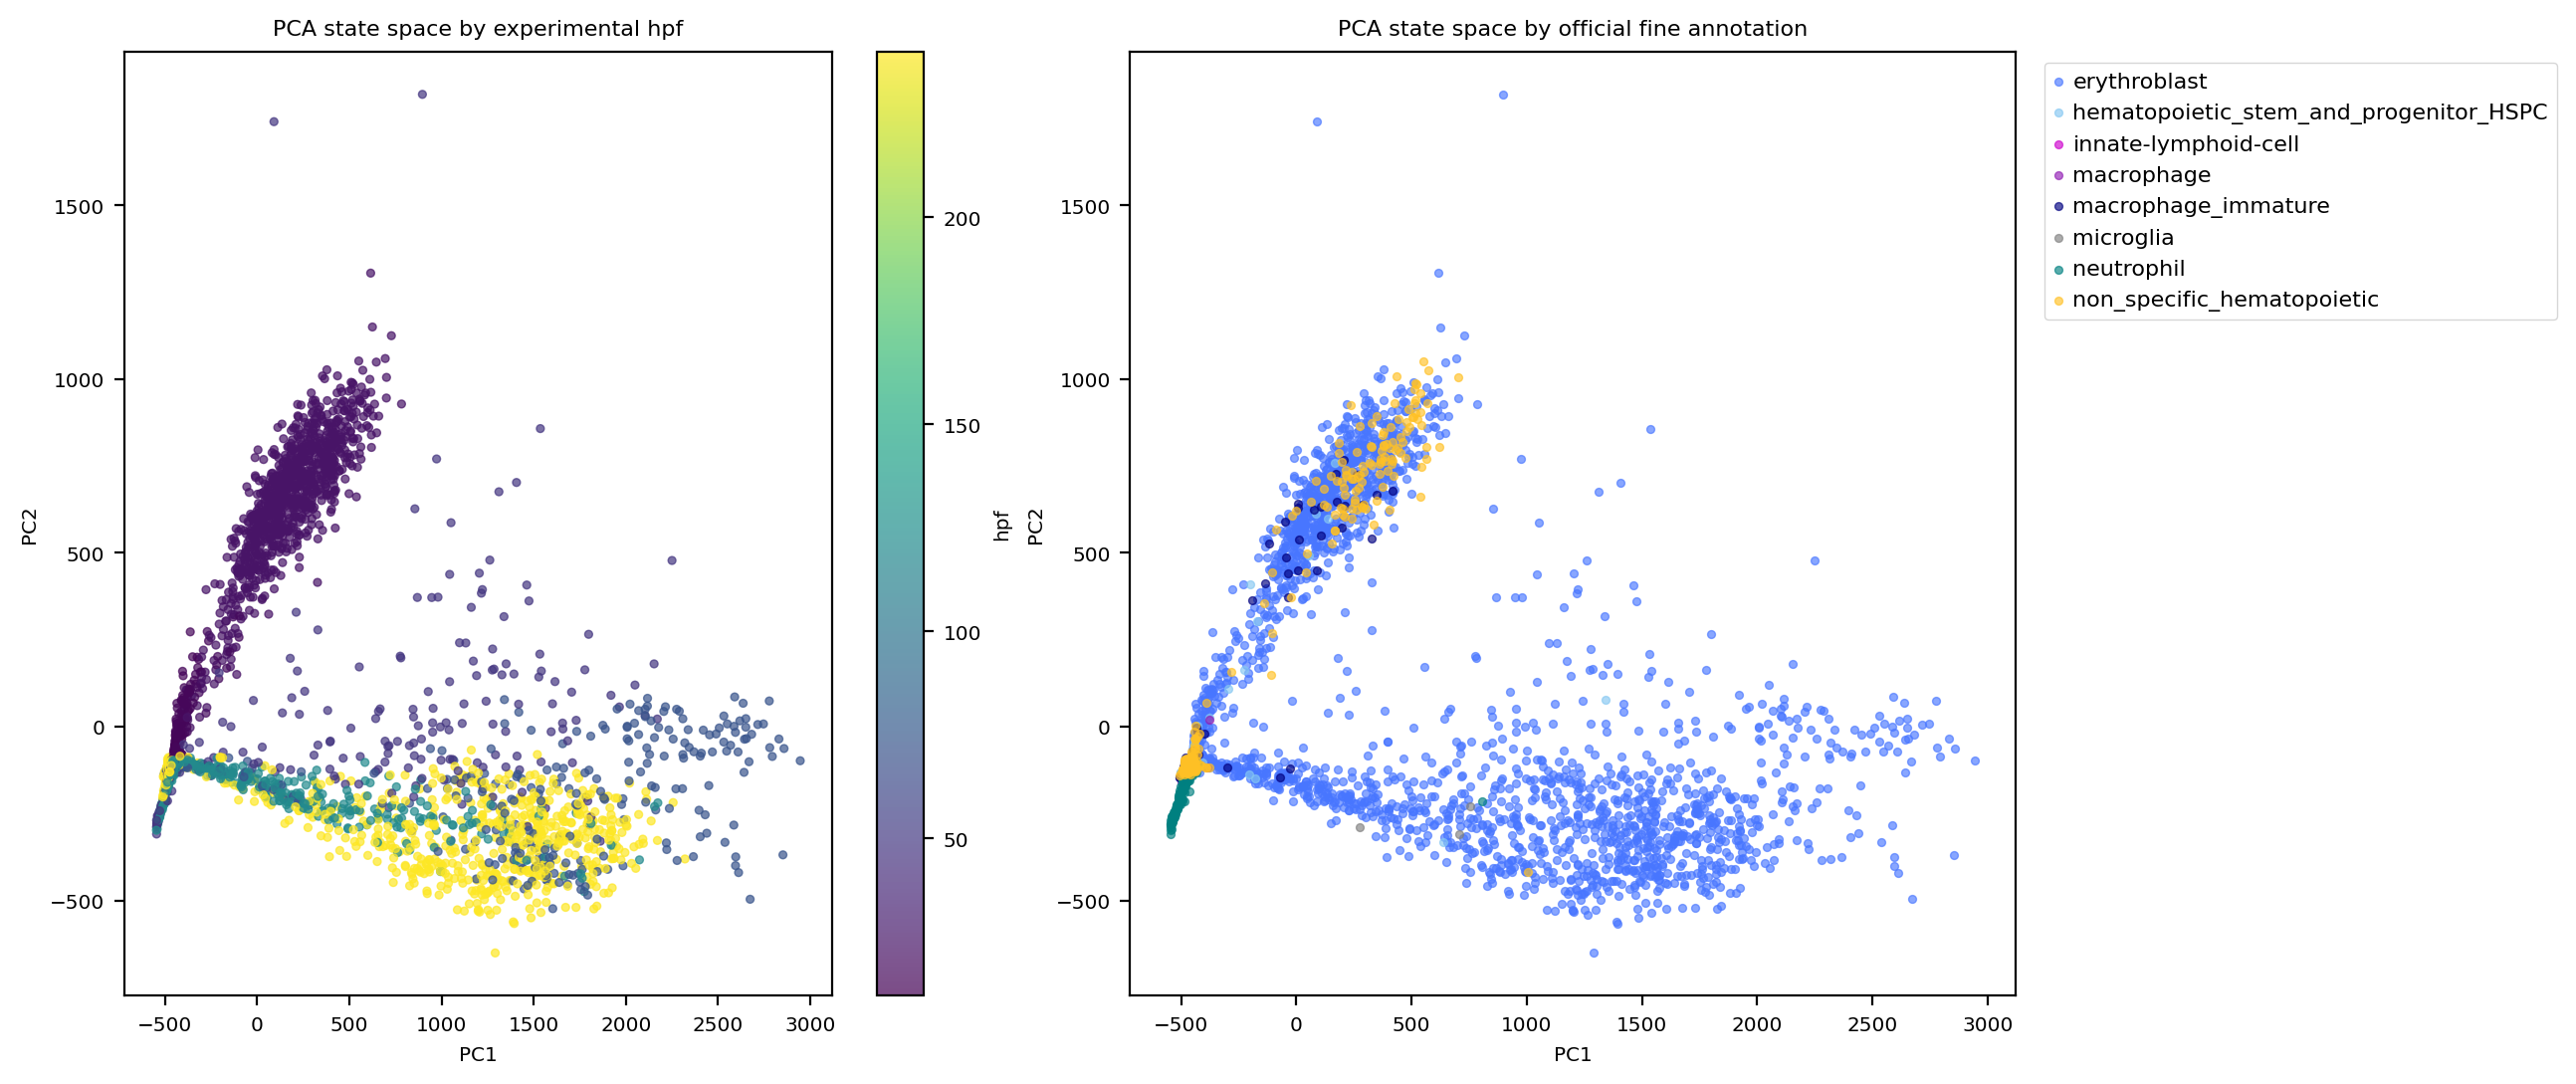

In [66]:
pcs = adata.obsm["X_pca"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

p = axes[0].scatter(
    pcs[:, 0], pcs[:, 1], c=adata.obs["hpf"], cmap="viridis",
    s=8, alpha=0.7, rasterized=True,
)
axes[0].set(title="PCA state space by experimental hpf", xlabel="PC1", ylabel="PC2")
fig.colorbar(p, ax=axes[0], label="hpf")

for official_label in adata.obs["model_cell_type"].cat.categories:
    mask = adata.obs["model_cell_type"].astype(str).eq(str(official_label)).to_numpy()
    axes[1].scatter(
        pcs[mask, 0], pcs[mask, 1], s=8, alpha=0.65,
        label=str(official_label), rasterized=True,
    )
axes[1].set(
    title="PCA state space by official fine annotation", xlabel="PC1", ylabel="PC2"
)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "official_fine_type_pca_state_space.pdf")
plt.show()


## 8. Audit graph continuity across real time

This diagnostic prevents overclaiming a continuous developmental trajectory
when the neighbor graph contains mostly within-stage edges.

In [67]:
C = (adata.obsp["connectivities"] > 0).astype(float).tocsr()
C_coo = C.tocoo()
hpf = adata.obs["hpf"].to_numpy(float)
edge_audit = pd.DataFrame({
    "source_hpf": hpf[C_coo.row],
    "target_hpf": hpf[C_coo.col],
})
edge_table = pd.crosstab(
    edge_audit["source_hpf"],
    edge_audit["target_hpf"],
    normalize="index",
)
display(edge_table.round(3))

same_hpf_fraction = np.mean(
    edge_audit["source_hpf"].to_numpy() == edge_audit["target_hpf"].to_numpy()
)
print(f"Same-hpf kNN edges: {same_hpf_fraction:.1%}")
if same_hpf_fraction > 0.90:
    warnings.warn(
        "More than 90% of kNN edges remain within the same hpf. Interpret "
        "velocity as local state dynamics; do not claim a single continuous "
        "trajectory spanning all sampled stages."
    )

target_hpf,12.0,14.0,16.0,19.0,24.0,48.0,72.0,120.0,240.0
source_hpf,,,,,,,,,
12.0,0.457,0.493,0.016,0.000,0.000,0.016,0.000,0.017,0.002
14.0,0.103,0.575,0.230,0.015,0.008,0.018,0.000,0.039,0.012
16.0,0.001,0.092,0.698,0.102,0.066,0.006,0.001,0.029,0.005
19.0,0.000,0.014,0.247,0.280,0.255,0.051,0.021,0.074,0.056
24.0,0.000,0.001,0.011,0.018,0.910,0.032,0.003,0.014,0.011
48.0,0.001,0.003,0.002,0.009,0.081,0.648,0.044,0.153,0.059
72.0,0.000,0.000,0.000,0.003,0.008,0.040,0.542,0.162,0.245
120.0,0.000,0.002,0.004,0.004,0.010,0.045,0.053,0.747,0.135
240.0,0.000,0.001,0.001,0.003,0.009,0.019,0.088,0.149,0.730


Same-hpf kNN edges: 73.8%


## 9. Dynamo moments and stochastic velocity

`recipe_monocle` has already created Dynamo-compatible normalized layers and
preprocessing flags. This section uses the current 30-neighbor PCA graph to compute
moments, followed by the stochastic steady-state dynamics model. No flags are manually
set to pretend that preprocessing occurred.

In [68]:
assert {"X_spliced", "X_unspliced"}.issubset(adata.layers.keys()), (
    "recipe_monocle did not create normalized X_spliced/X_unspliced layers."
)
A = (adata.obsp["connectivities"] > 0).astype(float).tocsr()
row_sums = np.asarray(A.sum(axis=1)).ravel()
assert np.all(row_sums > 0), "Neighbor graph contains isolated cells."
moments_conn = sp.diags(1.0 / row_sums) @ A

dynamics_genes = adata.var_names[adata.var["pass_basic_filter"].astype(bool)].tolist()
assert len(dynamics_genes) > 0
dyn.tl.moments(
    adata,
    genes=dynamics_genes,
    conn=moments_conn,
    normalize=False,
    use_gaussian_kernel=False,
    layers=["X_spliced", "X_unspliced"],
    n_neighbors=N_NEIGHBORS,
)
assert "M_s" in adata.layers and "M_u" in adata.layers

|-----> calculating first/second moments...
|-----> [moments calculation] completed [0.6983s]

╭─ SUMMARY: moments ─────────────────────────────────────────────────╮
│  Duration: 0.7013s                                                 │
│  Shape:    5,426 x 2,986 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSP   │ ✚ moments_con (sparse matrix, 5426x5426)               │
│                                                                    │
│  ● LAYERS │ ✚ M_s (sparse matrix, 5426x2986)                       │
│           │ ✚ M_ss (sparse matrix, 5426x2986)                      │
│           │ ✚ M_u (sparse matrix, 5426x2986)                       │
│           │ ✚ M_us (sparse matrix, 5426x2986)                      │
│           │ ✚ M_uu (sparse matrix, 5426x2986)      

In [71]:
dyn.tl.dynamics(
    adata,
    filter_gene_mode="final",
    use_smoothed=True,
    assumption_mRNA="ss",
    model="stochastic",
    est_method="gmm",
    log_unnormalized=False,
    re_smooth=False,
    del_2nd_moments=False,
    cores=1
)
assert "velocity_S" in adata.layers
print("Dynamo dynamics complete.")

estimating gamma: 100%|██████████| 951/951 [00:23<00:00, 40.01it/s]



╭─ SUMMARY: dynamics ────────────────────────────────────────────────╮
│  Duration: 25.4509s                                                │
│  Shape:    5,426 x 2,986 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● VAR    │ ✚ use_for_dynamics (bool)                              │
│                                                                    │
│  ● UNS    │ ✚ dynamics                                             │
│           │ ✚ vel_params_names                                     │
│                                                                    │
│  ● LAYERS │ ✚ velocity_S (sparse matrix, 5426x2986)                │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
Dynam

## 10. Velocity-gene quality control

The thresholds match the successful pilot:
`gamma > 0`, `gamma_r2 >= 0.01`, finite velocity in at least 95% of cells,
and spliced/unspliced detection in at least 25 cells. The number of passing
genes is data-dependent and is not hard-coded to the pilot's 272 genes.

In [72]:
vel_names = list(adata.uns["vel_params_names"])
vel_params = pd.DataFrame(
    adata.varm["vel_params"],
    index=adata.var_names,
    columns=vel_names,
)

V = adata.layers["velocity_S"]
V_dense = V.toarray() if sp.issparse(V) else np.asarray(V)

def detection_count(matrix):
    return np.asarray((matrix > 0).sum(axis=0)).ravel()

qc = pd.DataFrame(index=adata.var_names)
qc["gamma"] = pd.to_numeric(vel_params["gamma"], errors="coerce")
qc["gamma_r2"] = pd.to_numeric(vel_params["gamma_r2"], errors="coerce")
qc["velocity_finite_fraction"] = np.isfinite(V_dense).mean(axis=0)
qc["spliced_detected_cells"] = detection_count(adata.layers["spliced"])
qc["unspliced_detected_cells"] = detection_count(adata.layers["unspliced"])

valid_velocity_gene = (
    qc["gamma"].gt(0)
    & qc["gamma_r2"].ge(0.01)
    & qc["velocity_finite_fraction"].ge(0.95)
    & qc["spliced_detected_cells"].ge(25)
    & qc["unspliced_detected_cells"].ge(25)
)
adata.var["velocity_qc_pass"] = valid_velocity_gene.to_numpy()
transition_genes = adata.var_names[valid_velocity_gene].tolist()
qc.to_csv(RESULTS_DIR / "velocity_gene_qc.csv")

print("Velocity-QC genes:", len(transition_genes))
assert len(transition_genes) >= 50, (
    "Too few velocity-QC genes. Inspect dynamics and subtype composition "
    "before GraphVelo."
)

Velocity-QC genes: 522


In [ ]:
# qc -> 522 

## 11. GraphVelo in expression and PCA state spaces

If the installed GraphVelo source still uses SciPy sparse `.A`, replace those
package-internal occurrences with `.toarray()` once. Do not monkey-patch the
scientific data object.

In [74]:
# Compatibility bridge:
# convert the existing Scanpy neighbor graph into the neighbor-index
# format required by this installed GraphVelo version.

distances = adata.obsp["distances"].tocsr()
n_cells = adata.n_obs
n_neighbors = N_NEIGHBORS

neighbor_indices = np.empty(
    (n_cells, n_neighbors),
    dtype=np.int64,
)

for cell_index in range(n_cells):
    start = distances.indptr[cell_index]
    end = distances.indptr[cell_index + 1]

    row_neighbors = distances.indices[start:end]
    row_distances = distances.data[start:end]

    # Arrange existing neighbors by increasing PCA distance.
    order = np.argsort(row_distances)
    row_neighbors = row_neighbors[order]

    # Dynamo/GraphVelo-style index arrays normally include the cell itself.
    row_neighbors = row_neighbors[
        row_neighbors != cell_index
    ]

    selected = np.concatenate(
        [
            np.array([cell_index], dtype=np.int64),
            row_neighbors[: n_neighbors - 1],
        ]
    )

    # Padding is only needed in the unlikely case that a cell has fewer
    # graph neighbors than requested.
    if len(selected) < n_neighbors:
        selected = np.pad(
            selected,
            (0, n_neighbors - len(selected)),
            mode="edge",
        )

    neighbor_indices[cell_index] = selected

# Preserve the existing Scanpy graph and add only the format GraphVelo needs.
if "neighbors" not in adata.uns:
    adata.uns["neighbors"] = {}

adata.uns["neighbors"]["indices"] = neighbor_indices

print(
    "GraphVelo neighbor indices:",
    adata.uns["neighbors"]["indices"].shape,
)

assert adata.uns["neighbors"]["indices"].shape == (
    adata.n_obs,
    N_NEIGHBORS,
)

assert np.all(
    adata.uns["neighbors"]["indices"] >= 0
)

assert np.all(
    adata.uns["neighbors"]["indices"] < adata.n_obs
)

GraphVelo neighbor indices: (5426, 30)


In [75]:
from graphvelo.graph_velocity import GraphVelo

gene_mask = adata.var_names.isin(transition_genes)
X_train = adata.layers["M_s"][:, gene_mask]
V_train = adata.layers["velocity_S"][:, gene_mask]
assert np.isfinite(
    X_train.data if sp.issparse(X_train) else np.asarray(X_train)
).all()
assert np.isfinite(
    V_train.data if sp.issparse(V_train) else np.asarray(V_train)
).all()

gv = GraphVelo(
    adata,
    gene_subset=transition_genes,
    xkey="M_s",
    vkey="velocity_S",
)
gv.train()

adata.layers["velocity_gv"] = gv.project_velocity(adata.layers["M_s"])
adata.obsm["gv_pca"] = gv.project_velocity(adata.obsm["X_pca"])
gv.write_to_adata(adata, key="graphvelo")

assert adata.obsm["gv_pca"].shape == adata.obsm["X_pca"].shape
assert np.isfinite(adata.obsm["gv_pca"]).all()
print("GraphVelo training and PCA projection complete.")

ERROR:asyncio:Task was destroyed but it is pending!
task: <Task pending name='Task-527' coro=<_async_in_context.<locals>.run_in_context() done, defined at /net/dali/home/mscbio/jis322/.conda/envs/vae_gpu/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-528' coro=<Kernel.shell_main() running at /net/dali/home/mscbio/jis322/.conda/envs/vae_gpu/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /net/dali/home/mscbio/jis322/.conda/envs/vae_gpu/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
/net/dali/home/mscbio/jis322/.conda/envs/vae_gpu/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3557: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  return a.ndim
ERROR:asyncio:Task was destroyed but it is pending!
task: <Task pending name='Task-528' coro=<Kernel.shell_main() running at /net/dali/home/mscbio/jis322/.conda/envs/vae_gpu/lib/pyt

GraphVelo training and PCA projection complete.


In [76]:
V_input = np.asarray(gv.V)
V_fit = np.asarray(gv.project_velocity(gv.X))
input_norm = np.linalg.norm(V_input, axis=1)
fit_norm = np.linalg.norm(V_fit, axis=1)
denom = input_norm * fit_norm
fit_cosine = np.divide(
    np.sum(V_input * V_fit, axis=1),
    denom,
    out=np.full(len(denom), np.nan),
    where=denom > 0,
)
print(pd.Series(fit_cosine).describe())
if np.nanmedian(fit_cosine) <= 0:
    raise RuntimeError(
        "Median GraphVelo fit cosine is non-positive. Stop before interpreting "
        "directions or weights."
    )

projecting velocity vector to low dimensional embedding: 100%|██████████| 5426/5426 [00:00<00:00, 11889.85it/s]

count    5426.000000
mean        0.508466
std         0.152492
min         0.062338
25%         0.397115
50%         0.506277
75%         0.613106
max         0.918590
dtype: float64


## 12. Cell-level transition matrix and real-time constraint

Dynamo provides the neighbor transition matrix; GraphVelo refines state-space
velocities. We construct the cell transition matrix from GraphVelo PCA
velocities using neighbor displacement cosine similarity, retain positive
support, and remove edges that move backward by more than the allowed
experimental-time tolerance.

This is a real-time constraint, not pseudotime inference.

In [77]:
from sklearn.preprocessing import normalize

X_pca = np.asarray(adata.obsm["X_pca"])
V_pca = np.asarray(adata.obsm["gv_pca"])
distances = adata.obsp["distances"].tocsr()

rows, cols = distances.nonzero()
displacement = X_pca[cols] - X_pca[rows]
disp_norm = np.linalg.norm(displacement, axis=1)
vel_norm = np.linalg.norm(V_pca[rows], axis=1)
denom = disp_norm * vel_norm
cosine = np.divide(
    np.sum(displacement * V_pca[rows], axis=1),
    denom,
    out=np.zeros_like(denom),
    where=denom > 0,
)

# Positive cosine support; exp sharpens direction without inventing new edges.
edge_weight = np.where(cosine > 0, np.exp(5.0 * cosine), 0.0)
T_raw = sp.csr_matrix(
    (edge_weight, (rows, cols)),
    shape=(adata.n_obs, adata.n_obs),
)
T_raw.eliminate_zeros()
T_raw = normalize(T_raw, norm="l1", axis=1)

hpf = adata.obs["hpf"].to_numpy(float)
T_coo = T_raw.tocoo()
forward_time = hpf[T_coo.col] >= (hpf[T_coo.row] - TIME_TOLERANCE_HPF)
T_time = sp.csr_matrix(
    (
        T_coo.data[forward_time],
        (T_coo.row[forward_time], T_coo.col[forward_time]),
    ),
    shape=T_raw.shape,
)
T_time.eliminate_zeros()
T_time = normalize(T_time, norm="l1", axis=1)
adata.obsp["graphvelo_time_constrained_transition"] = T_time

valid_rows = np.asarray(T_time.sum(axis=1)).ravel() > 0
print("Cells with outgoing constrained transition:", valid_rows.sum(), "/", adata.n_obs)
assert valid_rows.mean() > 0.80, "Too many cells lost all outgoing transitions."

Cells with outgoing constrained transition: 5375 / 5426


## 13. Aggregate to directed official-cell-type weights

For source subtype \(A\) and target subtype \(B\):

$$ W_{A \rightarrow B} = \frac{\sum_{i\in A}\sum_{j\in B}T_{ij}} {\sum_{i\in A}\sum_jT_{ij}} $$

The table also reports the unconstrained forward-time fraction and weighted
mean change in hpf. Self-transitions are retained in the CSV but may be hidden
from the lineage figure.

In [78]:
cell_types = adata.obs["official_fine_cell_type"].astype(str).to_numpy()
unique_cell_types = sorted(pd.unique(cell_types))

T_raw_coo = T_raw.tocoo()
raw_edges = pd.DataFrame({
    "source": cell_types[T_raw_coo.row],
    "target": cell_types[T_raw_coo.col],
    "weight": T_raw_coo.data,
    "delta_hpf": hpf[T_raw_coo.col] - hpf[T_raw_coo.row],
})

T_time_coo = T_time.tocoo()
time_edges = pd.DataFrame({
    "source": cell_types[T_time_coo.row],
    "target": cell_types[T_time_coo.col],
    "weight": T_time_coo.data,
    "delta_hpf": hpf[T_time_coo.col] - hpf[T_time_coo.row],
})

raw_stats = raw_edges.groupby(["source", "target"], observed=True).apply(
    lambda d: pd.Series({
        "forward_time_fraction_raw": np.average(
            d["delta_hpf"] >= -TIME_TOLERANCE_HPF, weights=d["weight"]
        )
    }),
)
time_group = time_edges.groupby(["source", "target"], observed=True)
weights = time_group["weight"].sum().rename("edge_mass")
mean_delta = time_group.apply(
    lambda d: np.average(d["delta_hpf"], weights=d["weight"]),
).rename("mean_delta_hpf")

transition = pd.concat([weights, mean_delta, raw_stats], axis=1).reset_index()
source_mass = transition.groupby("source")["edge_mass"].transform("sum")
transition["weight"] = transition["edge_mass"] / source_mass
transition = transition.sort_values(["source", "weight"], ascending=[True, False])
transition.to_csv(RESULTS_DIR / "official_type_transition_weights.csv", index=False)
display(transition)


/tmp/ipykernel_431891/2103985998.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  raw_stats = raw_edges.groupby(["source", "target"], observed=True).apply(
/tmp/ipykernel_431891/2103985998.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mean_delta = time_group.apply(


,source,target,edge_mass,mean_delta_hpf,forward_time_fraction_raw,weight
0,erythroblast,erythroblast,2036.879998,6.463138,0.917790,0.869718
7,erythroblast,non_specific_hematopoietic,110.447720,5.876632,0.974649,0.047160
1,erythroblast,hematopoietic_stem_and_progenitor_HSPC,76.075992,19.700060,0.926491,0.032483
4,erythroblast,macrophage_immature,63.477838,7.993082,0.851426,0.027104
3,erythroblast,macrophage,37.599928,13.600177,0.798386,0.016055
...,...,...,...,...,...,...
55,non_specific_hematopoietic,hematopoietic_stem_and_progenitor_HSPC,58.892163,40.774178,0.962683,0.128026
58,non_specific_hematopoietic,macrophage_immature,43.860717,10.806143,0.915650,0.095349
59,non_specific_hematopoietic,microglia,15.376735,21.038003,0.879272,0.033428
56,non_specific_hematopoietic,innate-lymphoid-cell,1.474629,36.176869,0.729807,0.003206


## 14. Fish-level bootstrap confidence intervals

Fish—not individual cells—is the resampling unit. This avoids treating many
cells from one fish as independent biological replicates.

In [79]:
rng = np.random.default_rng(SEED)
fish = adata.obs["fish_id"].astype(str).to_numpy()
unique_fish = np.unique(fish)
N_BOOT = 500

def aggregate_transition_for_cells(cell_indices):
    sub = T_time[cell_indices, :]
    records = []
    for source_name in unique_cell_types:
        local_rows = np.flatnonzero(cell_types[cell_indices] == source_name)
        if len(local_rows) == 0:
            continue
        block = sub[local_rows, :]
        masses = [
            (target_name, float(block[:, cell_types == target_name].sum()))
            for target_name in unique_cell_types
        ]
        total = sum(mass for _, mass in masses)
        if total > 0:
            records.extend(
                (source_name, target_name, mass / total)
                for target_name, mass in masses
            )
    return records

bootstrap_records = []
for iteration in range(N_BOOT):
    sampled_fish = rng.choice(unique_fish, size=len(unique_fish), replace=True)
    sampled_cells = np.concatenate([
        np.flatnonzero(fish == fish_id) for fish_id in sampled_fish
    ])
    for source_name, target_name, value in aggregate_transition_for_cells(sampled_cells):
        bootstrap_records.append((iteration, source_name, target_name, value))

boot = pd.DataFrame(
    bootstrap_records, columns=["iteration", "source", "target", "weight"]
)
ci = (
    boot.groupby(["source", "target"])["weight"]
    .quantile([0.025, 0.975]).unstack()
    .rename(columns={0.025: "weight_ci_low", 0.975: "weight_ci_high"})
    .reset_index()
)
transition_ci = transition.merge(ci, on=["source", "target"], how="left")
transition_ci.to_csv(
    RESULTS_DIR / "official_type_transition_weights_bootstrap.csv", index=False
)
display(transition_ci)


,source,target,edge_mass,mean_delta_hpf,forward_time_fraction_raw,weight,weight_ci_low,weight_ci_high
0,erythroblast,erythroblast,2036.879998,6.463138,0.917790,0.869718,0.826691,0.902673
1,erythroblast,non_specific_hematopoietic,110.447720,5.876632,0.974649,0.047160,0.025806,0.070264
2,erythroblast,hematopoietic_stem_and_progenitor_HSPC,76.075992,19.700060,0.926491,0.032483,0.023230,0.046315
3,erythroblast,macrophage_immature,63.477838,7.993082,0.851426,0.027104,0.018206,0.039424
4,erythroblast,macrophage,37.599928,13.600177,0.798386,0.016055,0.008963,0.027139
...,...,...,...,...,...,...,...,...
57,non_specific_hematopoietic,hematopoietic_stem_and_progenitor_HSPC,58.892163,40.774178,0.962683,0.128026,0.081250,0.192093
58,non_specific_hematopoietic,macrophage_immature,43.860717,10.806143,0.915650,0.095349,0.061874,0.146769
59,non_specific_hematopoietic,microglia,15.376735,21.038003,0.879272,0.033428,0.016909,0.057031
60,non_specific_hematopoietic,innate-lymphoid-cell,1.474629,36.176869,0.729807,0.003206,0.000839,0.006104


## 15. Main result: directed weighted official-cell-type network

Nodes are validated official cell types; node size is cell count; node color is
median experimental hpf; edge width is transition weight. Only cross-subtype
edges above the display threshold are plotted.

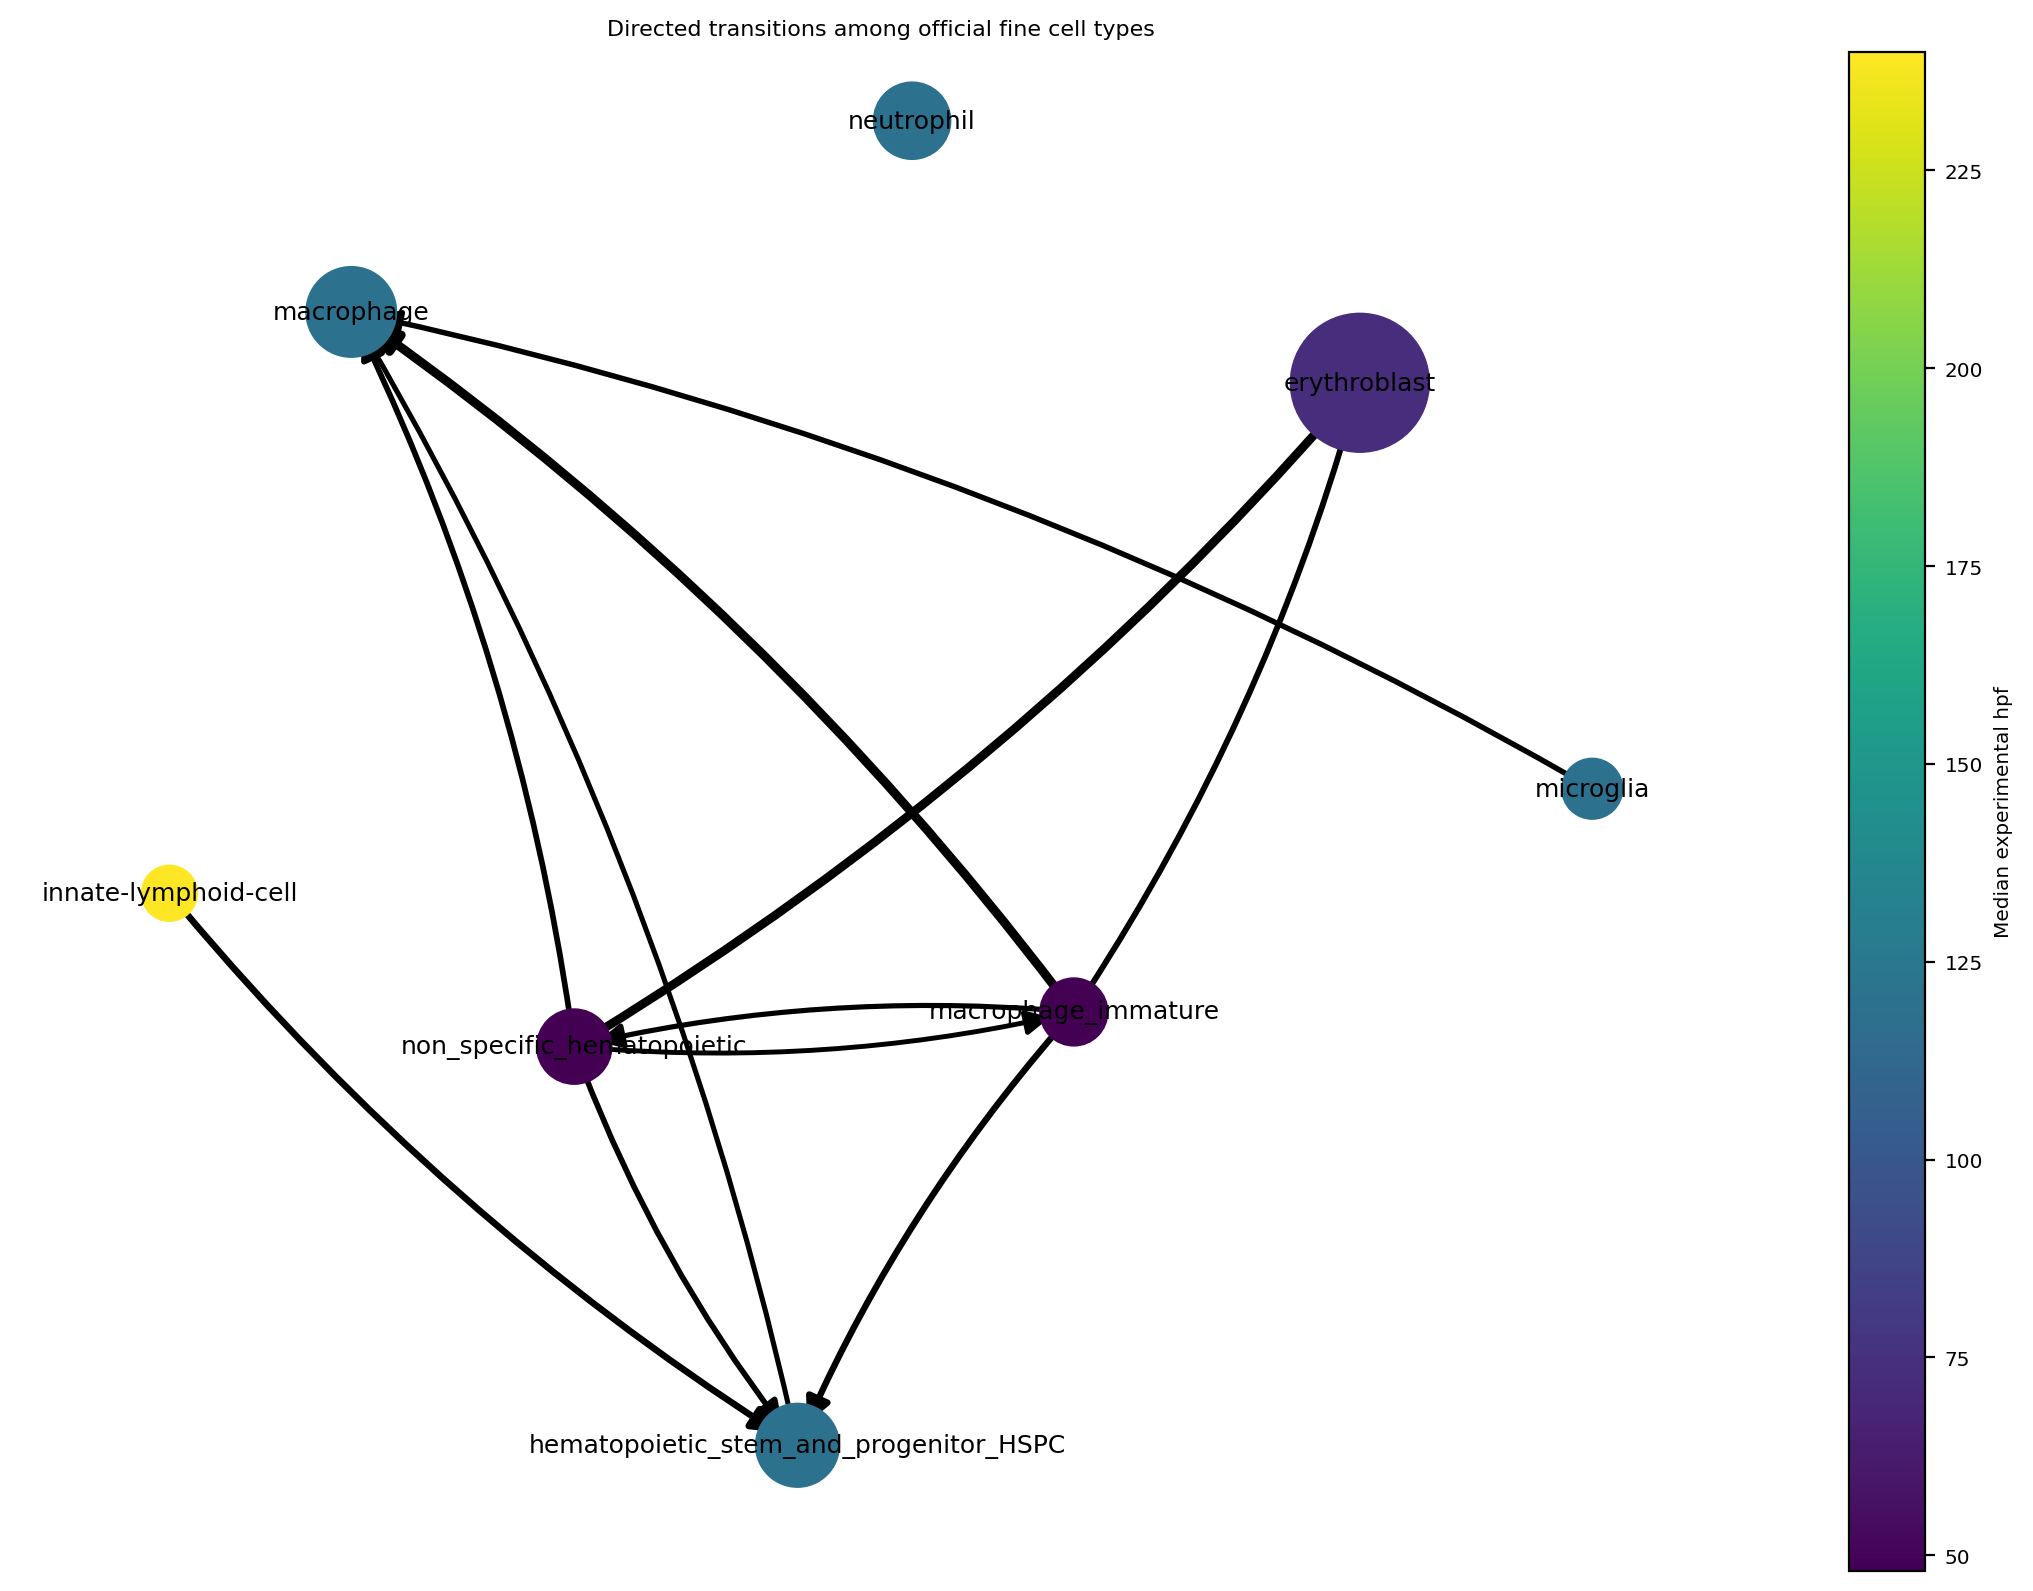

In [92]:
DISPLAY_WEIGHT = 0.09 # if over .0 the neutrophil would be isolated, .03 has 1 edge, .02 have 2 edges
network_edges = transition_ci[
    (transition_ci["source"] != transition_ci["target"])
    & (transition_ci["weight"] >= DISPLAY_WEIGHT)
].copy()

G = nx.DiGraph()
node_stats = (
    adata.obs.groupby("official_fine_cell_type", observed=True)
    .agg(n_cells=("fish_id", "size"), median_hpf=("hpf", "median"))
)
for label, row in node_stats.iterrows():
    G.add_node(str(label), **row.to_dict())
for row in network_edges.itertuples(index=False):
    G.add_edge(row.source, row.target, weight=row.weight)

fig, ax = plt.subplots(figsize=(11, 8))
pos = nx.spring_layout(G, seed=SEED, k=1.3)
sizes = [300 + 2200 * node_stats.loc[n, "n_cells"] / node_stats["n_cells"].max()
         for n in G.nodes]
colors = [node_stats.loc[n, "median_hpf"] for n in G.nodes]
nodes = nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors,
                               cmap="viridis", ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)
nx.draw_networkx_edges(
    G, pos, width=[1 + 8 * G[u][v]["weight"] for u, v in G.edges],
    arrows=True, arrowsize=18, connectionstyle="arc3,rad=0.08", ax=ax,
)
fig.colorbar(nodes, ax=ax, label="Median experimental hpf")
ax.set_title("Directed transitions among official fine cell types")
ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "official_fine_type_lineage_network.pdf")
plt.show()


In [ ]:
# change: Aug_6th
# use SGHMC to embedding the time traj  and bound the development of cells groups
# four branches
# SGDL
# moscot
# 

## 16. Optional ODE trajectories in PCA space

ODE fitting is intentionally disabled by default. First inspect the official inventory,
then set `HSPC_OFFICIAL_LABEL` and `ODE_BRANCHES` using exact official annotation values.
This prevents the notebook from inventing an HSPC state or branch hierarchy.


In [ ]:
# ODE does not work??

In [93]:
HSPC_LABEL = ("hematopoietic_stem_and_progenitor_HSPC")
# transite weight
display(transition_ci.loc[transition_ci["source"].eq(HSPC_LABEL),
        [
            "source",
            "target",
            "weight",
            "weight_ci_low",
            "weight_ci_high",
            "mean_delta_hpf",
        ],
    ]
    .sort_values("weight", ascending=False)
)

,source,target,weight,weight_ci_low,weight_ci_high,mean_delta_hpf
8,hematopoietic_stem_and_progenitor_HSPC,hematopoietic_stem_and_progenitor_HSPC,0.681661,0.570064,0.768235,22.066069
9,hematopoietic_stem_and_progenitor_HSPC,macrophage,0.103849,0.059037,0.165684,10.406503
10,hematopoietic_stem_and_progenitor_HSPC,non_specific_hematopoietic,0.066969,0.056901,0.078986,27.638454
11,hematopoietic_stem_and_progenitor_HSPC,macrophage_immature,0.057079,0.030897,0.091694,19.660189
12,hematopoietic_stem_and_progenitor_HSPC,erythroblast,0.051458,0.030876,0.091351,17.933795
13,hematopoietic_stem_and_progenitor_HSPC,neutrophil,0.030913,0.017932,0.043365,14.602797
14,hematopoietic_stem_and_progenitor_HSPC,innate-lymphoid-cell,0.006978,0.004279,0.010815,30.154227
15,hematopoietic_stem_and_progenitor_HSPC,microglia,0.001094,0.000000,0.003963,47.767498


In [95]:
HSPC_OFFICIAL_LABEL = (
    "hematopoietic_stem_and_progenitor_HSPC"
)

ODE_BRANCHES = [
    (
        "erythroid_branch",
        [
            "hematopoietic_stem_and_progenitor_HSPC",
            "non_specific_hematopoietic",
            "erythroblast",
        ],
    ),
    (
        "macrophage_branch",
        [
            "hematopoietic_stem_and_progenitor_HSPC",
            "macrophage_immature",
            "macrophage",
        ],
    ),
    (
        "neutrophil_branch",
        [
            "hematopoietic_stem_and_progenitor_HSPC",
            "non_specific_hematopoietic",
            "neutrophil",
        ],
    ),
    (
        "innate_lymphoid_branch",
        [
            "hematopoietic_stem_and_progenitor_HSPC",
            "innate-lymphoid-cell",
        ],
    ),
]

In [96]:
from scipy.integrate import solve_ivp
from sklearn.neighbors import KNeighborsRegressor

official_label_set = set(unique_cell_types)
configured_branches = []
for branch_name, labels in ODE_BRANCHES:
    missing = sorted(set(labels) - official_label_set)
    assert not missing, f"ODE branch {branch_name!r} contains non-official labels: {missing}"
    configured_branches.append((branch_name, list(labels)))

if configured_branches:
    assert HSPC_OFFICIAL_LABEL in official_label_set, (
        "Set HSPC_OFFICIAL_LABEL to an exact official annotation."
    )
    assert all(HSPC_OFFICIAL_LABEL in labels for _, labels in configured_branches)

ODE_PCS = min(10, X_pca.shape[1])
N_STARTS = 5
T_SPAN = (0.0, 5.0)
T_EVAL = np.linspace(*T_SPAN, 150)
ode_trajectories = {}

for branch_name, labels in configured_branches:
    mask = np.isin(cell_types, labels)
    X_branch = X_pca[mask, :ODE_PCS]
    V_branch = V_pca[mask, :ODE_PCS]
    field = KNeighborsRegressor(
        n_neighbors=min(ODE_K_NEIGHBORS, len(X_branch)),
        weights="distance",
        n_jobs=-1,
    ).fit(X_branch, V_branch)

    starts_all = np.flatnonzero(cell_types == HSPC_OFFICIAL_LABEL)
    earliest_hpf = np.min(hpf[starts_all])
    starts = starts_all[hpf[starts_all] == earliest_hpf]
    if len(starts) > N_STARTS:
        starts = rng.choice(starts, size=N_STARTS, replace=False)

    solutions = []
    for cell_index in starts:
        solution = solve_ivp(
            fun=lambda _, x: field.predict(x.reshape(1, -1))[0],
            t_span=T_SPAN, y0=X_pca[cell_index, :ODE_PCS], t_eval=T_EVAL,
            rtol=1e-5, atol=1e-7,
        )
        solutions.append(solution.y.T)
    ode_trajectories[branch_name] = solutions

if not configured_branches:
    print("ODE skipped: choose exact official labels in section 0 after reviewing inventory.")
else:
    print("ODE branches fitted:", [name for name, _ in configured_branches])


ODE branches fitted: ['erythroid_branch', 'macrophage_branch', 'neutrophil_branch', 'innate_lymphoid_branch']


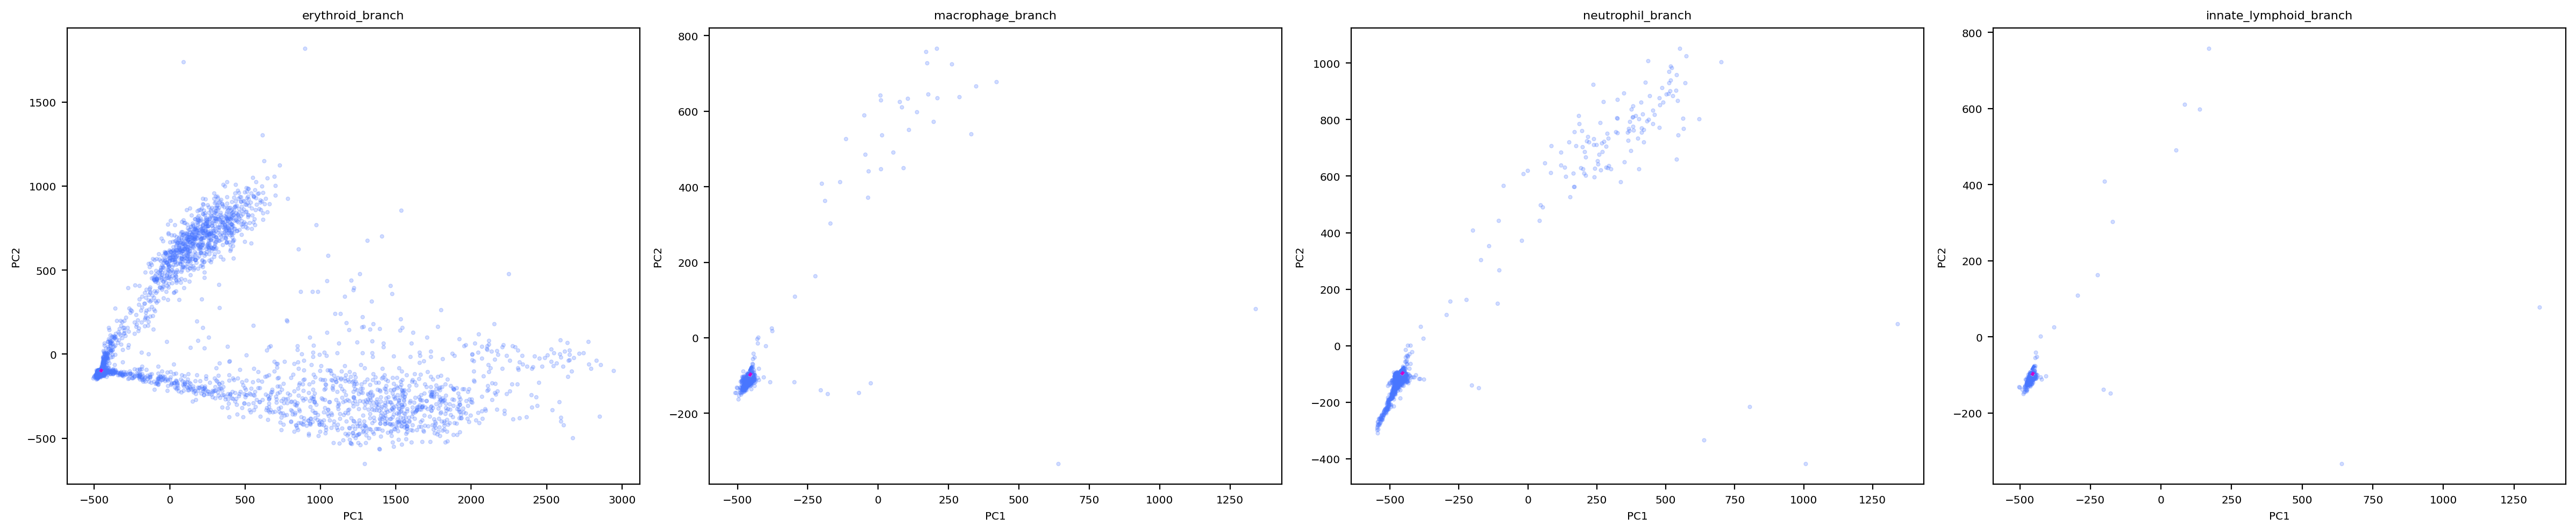

In [99]:
if ode_trajectories:
    fig, axes = plt.subplots(
        1, len(configured_branches),
        figsize=(6 * len(configured_branches), 5),
        squeeze=False,
    )

    for ax, (branch_name, labels) in zip(axes[0], configured_branches):
        solutions = ode_trajectories[branch_name]
        branch_mask = np.isin(cell_types, labels)

        ax.scatter(
            X_pca[branch_mask, 0], X_pca[branch_mask, 1],
            s=6, alpha=0.25,
        )

        for trajectory in solutions:
            ax.plot(trajectory[:, 0], trajectory[:, 1], linewidth=2)

        ax.set(title=branch_name, xlabel="PC1", ylabel="PC2")

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "official_label_ode_trajectories.pdf")
    plt.show()

## 17. Human ortholog handoff

Ortholog mapping should be performed with a versioned source such as ZFIN or

Ensembl BioMart. Zebrafish paralogs must not be converted by merely uppercasing
gene symbols. This notebook exports the branch-relevant zebrafish genes and a
template for a separately provenance-tracked mapping.

In [ ]:
branch_gene_scores = pd.DataFrame(index=adata.var_names)
branch_gene_scores["velocity_qc_pass"] = adata.var["velocity_qc_pass"].astype(bool)
# branch_gene_scores["mean_abs_graphvelo_velocity"] = np.mean(np.abs(np.asarray(adata.layers["velocity_gv"])), axis=0)

# velocity_gv is sparse
V_gv = adata.layers["velocity_gv"]

if sp.issparse(V_gv):
    mean_abs_velocity = np.asarray(abs(V_gv).mean(axis=0)).ravel()
    # convert 2D into 1D
else:
    mean_abs_velocity = np.mean(np.abs(V_gv),axis=0)

branch_gene_scores[
    "mean_abs_graphvelo_velocity"
] = mean_abs_velocity


branch_gene_scores["expression_variance"] = np.var22  R    (
    adata.layers["M_s"].toarray()
    if sp.issparse(adata.layers["M_s"])
    else np.asarray(adata.layers["M_s"]),
    axis=0,
)
branch_gene_scores = branch_gene_scores.sort_values(
    ["velocity_qc_pass", "mean_abs_graphvelo_velocity"],
    ascending=False,
)
branch_gene_scores.to_csv(RESULTS_DIR / "zebrafish_dynamic_gene_candidates.csv")

ortholog_template = pd.DataFrame(columns=[
    "zebrafish_gene",
    "human_ortholog",
    "orthology_type",
    "source_database",
    "source_release",
    "retrieval_date",
])
ortholog_template.to_csv(RESULTS_DIR / "zebrafish_human_ortholog_template.csv", index=False)
display(branch_gene_scores.head(50))

## 18. Save the auditable checkpoint and manifest

The checkpoint contains only the clean blood-cell analysis and its derived
objects. The original full dataset remains unchanged.

In [91]:
adata.uns["clean_analysis_manifest"] = {
    "input_h5ad": str(INPUT_H5AD),
    "lineage_h5ad": str(LINEAGE_H5AD),
    "annotation_source_column": LINEAGE_ANNOTATION_COL,
    "timepoint_source_column": LINEAGE_TIMEPOINT_COL,
    "annotation_merge": "exact_cell_id_reindex",
    "uses_cluster_name_dictionary": False,
    "uses_keyword_cell_type_mapping": False,
    "uses_handwritten_marker_dictionary": False,
    "candidate_marker_method": "wilcoxon_each_official_type_vs_rest",
    "dynamo_preprocessing": "recipe_monocle_once_on_working_copy",
    "uses_pseudotime": False,
    "uses_scvelo": False,
    "uses_cellrank": False,
    "principal_state_space": "PCA",
    "experimental_time_column": "hpf",
    "fine_annotation_column": "official_fine_cell_type",
    "fish_column": FISH_COL,
    "n_neighbors": N_NEIGHBORS,
    "ode_k_neighbors": ODE_K_NEIGHBORS,
    "time_tolerance_hpf": TIME_TOLERANCE_HPF,
    "modeled_official_labels": modeled_labels,
}

checkpoint = CHECKPOINT_DIR / "blood_graphvelo_official_annotations.h5ad"
adata.write_h5ad(checkpoint, compression="lzf")

manifest = {
    "checkpoint": str(checkpoint),
    "tables": sorted(str(p) for p in RESULTS_DIR.glob("*.csv")),
    "figures": sorted(str(p) for p in FIGURE_DIR.glob("*.pdf")),
}
with open(RESULTS_DIR / "manifest.json", "w") as handle:
    json.dump(manifest, handle, indent=2)
print(json.dumps(manifest, indent=2))


{
  "checkpoint": "/net/dali/home/mscbio/jis322/dynamo/blood_graphvelo_official/checkpoints/blood_graphvelo_official_annotations.h5ad",
  "tables": [
    "/net/dali/home/mscbio/jis322/dynamo/blood_graphvelo_official/results/data_driven_candidate_markers.csv",
    "/net/dali/home/mscbio/jis322/dynamo/blood_graphvelo_official/results/official_fine_annotation_inventory.csv",
    "/net/dali/home/mscbio/jis322/dynamo/blood_graphvelo_official/results/official_fine_annotation_summary.csv",
    "/net/dali/home/mscbio/jis322/dynamo/blood_graphvelo_official/results/official_fine_cell_type_counts.csv",
    "/net/dali/home/mscbio/jis322/dynamo/blood_graphvelo_official/results/official_type_time_fish_counts.csv",
    "/net/dali/home/mscbio/jis322/dynamo/blood_graphvelo_official/results/official_type_transition_weights.csv",
    "/net/dali/home/mscbio/jis322/dynamo/blood_graphvelo_official/results/official_type_transition_weights_bootstrap.csv",
    "/net/dali/home/mscbio/jis322/dynamo/blood_graphve

## Interpretation checklist

Before reporting:

1. Confirm that `official_fine_cell_type` exactly matches the reindexed
   `lineage.obs["annotation"]` values.
2. Confirm every lineage `timepoint` value appears correctly in the displayed
   timepoint-to-hpf conversion audit.
3. Treat `clusters` and `seurat_clusters` as audit variables only.
4. Review data-derived candidate markers without changing official names; validate important
   candidates separately against literature or an external reference.
5. Report cell and fish counts across hpf and stage imbalance.
6. Report GraphVelo fit diagnostics and velocity-gene QC.
7. Interpret transition weights as model-supported directed relationships—not direct
   lineage-tracing probabilities.
8. Run ODE branches only after an official label genuinely represents the intended
   starting population.
